In [1]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [2]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import numpy as np
import matplotlib.pyplot as plt

In [3]:
(X_train,y_train),(X_test,y_test)=datasets.cifar10.load_data()

In [4]:
X_test.shape

(10000, 32, 32, 3)

In [5]:
X_train.shape

(50000, 32, 32, 3)

In [6]:
y_train.shape

(50000, 1)

In [7]:
y_train[:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

In [8]:
y_train=y_train.reshape(-1,)
y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

In [9]:
y_test=y_test.reshape(-1,)

In [10]:
classes=['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

In [11]:
def plot_sample(X,y,index):
    plt.figure(figsize=(15,2))
    plt.imshow(X[index])
    plt.xlabel(classes[y[index]])

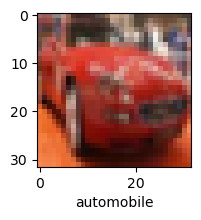

In [12]:
plot_sample(X_train,y_train,5)

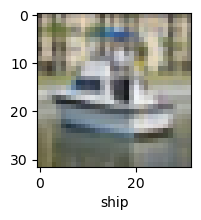

In [13]:
plot_sample(X_train,y_train,501)

In [14]:
X_train=X_train/255.0
X_test=X_test/255.0

In [15]:
ann = models.Sequential([
    layers.Flatten(input_shape=(32,32,3)),
    layers.Dense(3000,activation='relu'),
    layers.Dense(1000,activation='relu'),
    layers.Dense(10,activation='softmax')
])

ann.compile(optimizer ='SGD',
          loss='sparse_categorical_crossentropy',
          metrics=['accuracy'])

ann.fit(X_train,y_train,epochs=5)

C:\Users\Polok\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 21ms/step - accuracy: 0.3540 - loss: 1.8142
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - accuracy: 0.4271 - loss: 1.6237
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 21ms/step - accuracy: 0.4568 - loss: 1.5419
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 32s 21ms/step - accuracy: 0.4790 - loss: 1.4813
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 32s 21ms/step - accuracy: 0.4938 - loss: 1.4320


In [16]:
from sklearn.metrics import confusion_matrix,classification_report
import numpy as np
y_pred=ann.predict(X_test)
y_pred_classes=[np.argmax(element) for element in y_pred]

print('classification report: \n',classification_report(y_test,y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step
classification report: 
               precision    recall  f1-score   support

           0       0.57      0.55      0.56      1000
           1       0.74      0.41      0.53      1000
           2       0.42      0.24      0.31      1000
           3       0.25      0.57      0.35      1000
           4       0.55      0.23      0.32      1000
           5       0.42      0.30      0.35      1000
           6       0.39      0.72      0.51      1000
           7       0.65      0.40      0.50      1000
           8       0.71      0.51      0.60      1000
           9       0.49      0.66      0.56      1000

    accuracy                           0.46     10000
   macro avg       0.52      0.46      0.46     10000
weighted avg       0.52      0.46      0.46     10000



In [17]:
import seaborn as sns

<function matplotlib.pyplot.show(close=None, block=None)>

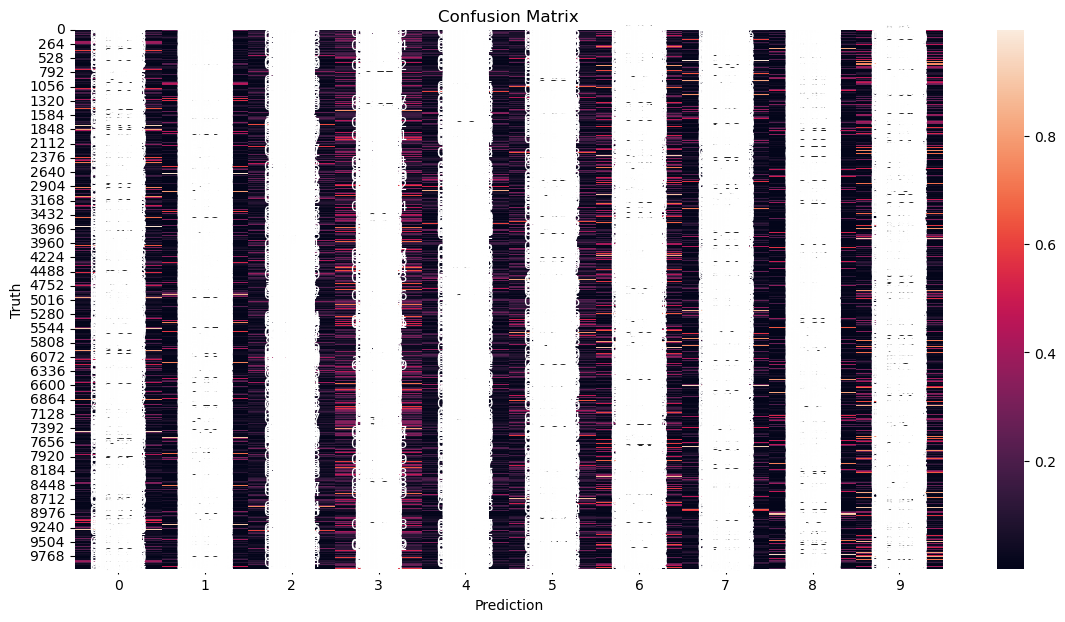

In [18]:
plt.figure(figsize=(14,7))
sns.heatmap(y_pred,annot=True)
plt.ylabel('Truth')
plt.xlabel('Prediction')
plt.title('Confusion Matrix')
plt.show

In [19]:
cnn = models.Sequential([
    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

C:\Users\Polok\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
cnn.compile(optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

In [21]:
cnn.fit(X_train,y_train,epochs=10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.4614 - loss: 1.5028
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - accuracy: 0.5927 - loss: 1.1599
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.6421 - loss: 1.0288
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.6691 - loss: 0.9525
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.6917 - loss: 0.8910
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.7076 - loss: 0.8417
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.7231 - loss: 0.7996
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.7371 - loss: 0.7589
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.7453 - loss: 0.7296
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.7572 - loss: 0.6976


In [22]:
cnn.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6996 - loss: 0.8936


[0.8935801982879639, 0.6995999813079834]

In [23]:
y_pred = cnn.predict(X_test)
y_pred[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


array([[9.15075000e-03, 9.16366174e-04, 1.51037425e-02, 8.18623781e-01,
        7.83725467e-04, 3.70404832e-02, 4.82931957e-02, 5.42527014e-05,
        6.97492287e-02, 2.84487061e-04],
       [2.98925000e-03, 4.68904004e-02, 6.70932593e-07, 1.27176989e-07,
        4.43181136e-07, 1.28406552e-09, 4.06306135e-08, 4.85600715e-08,
        9.49795604e-01, 3.23428045e-04],
       [1.29616885e-02, 3.89244184e-02, 9.27691115e-04, 2.89328862e-02,
        1.64544710e-03, 2.31320411e-03, 3.66442429e-04, 1.61574411e-04,
        9.12812769e-01, 9.53910523e-04],
       [6.66953325e-01, 8.25263485e-02, 1.81483313e-01, 1.62623997e-04,
        1.14771249e-02, 4.57667102e-06, 7.27216597e-04, 1.23007820e-04,
        5.65155260e-02, 2.69058510e-05],
       [7.04457489e-06, 4.48272476e-05, 5.48490090e-03, 3.39291021e-02,
        4.68056202e-01, 6.02132501e-03, 4.85946864e-01, 7.74685759e-05,
        4.12769266e-04, 1.95072626e-05]], dtype=float32)

In [24]:
y_classes=[np.argmax(element) for element in y_pred]
y_classes[:5]

[np.int64(3), np.int64(8), np.int64(8), np.int64(0), np.int64(6)]

In [25]:
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)

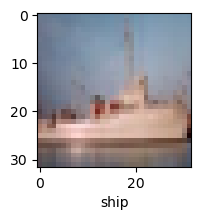

In [26]:
plot_sample(X_test,y_test,185)

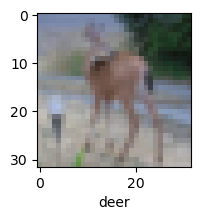

In [27]:
plot_sample(X_test,y_test,100)

In [28]:
classes[y_classes[185]]

'ship'

Enhanced CNN Model

In [29]:
cnn_new = models.Sequential([

    #Block 1
    layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    #Block 2
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    #Block 3
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

In [30]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1,
    rotation_range=10,
    zoom_range=0.1
)


In [31]:
cnn_new.compile(optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

In [32]:
cnn_new.fit(datagen.flow(X_train, y_train, batch_size=32), epochs=10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 62s 37ms/step - accuracy: 0.3687 - loss: 1.7527
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 58s 37ms/step - accuracy: 0.5092 - loss: 1.3841
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 60s 38ms/step - accuracy: 0.5836 - loss: 1.1963
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 60s 39ms/step - accuracy: 0.6344 - loss: 1.0629
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 59s 38ms/step - accuracy: 0.6647 - loss: 0.9791
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 61s 39ms/step - accuracy: 0.6898 - loss: 0.9156
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 59s 38ms/step - accuracy: 0.7057 - loss: 0.8623
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 61s 39ms/step - accuracy: 0.7230 - loss: 0.8166
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 62s 39ms/step - accuracy: 0.7399 - loss: 0.7755
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 61s 39ms/step - accuracy: 0.7483 - loss: 0.7462


In [33]:
# Evaluate Enhanced CNN
cnn_new.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.7620 - loss: 0.7068


[0.7067780494689941, 0.7620000243186951]

In [34]:
y_pred_new = cnn_new.predict(X_test)
y_pred_new[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step


array([[6.7508256e-04, 2.7607800e-04, 7.4050715e-03, 7.6519173e-01,
        2.4519560e-03, 7.9498701e-02, 1.4030676e-01, 1.2511308e-03,
        2.6535918e-03, 2.8990422e-04],
       [1.5167972e-04, 5.9407357e-02, 1.6159970e-07, 3.0430724e-07,
        3.0001761e-09, 6.3251639e-09, 1.1719492e-06, 2.7663169e-10,
        9.4041783e-01, 2.1527907e-05],
       [1.4188788e-02, 4.9926151e-02, 3.1133626e-02, 5.7763797e-03,
        1.9096617e-03, 2.8179440e-04, 1.3009796e-01, 8.1006023e-05,
        7.6259780e-01, 4.0068636e-03],
       [4.2242733e-01, 2.4311848e-02, 3.3006165e-02, 3.1832284e-03,
        3.8094244e-03, 3.8029137e-04, 1.9626438e-03, 8.0171373e-04,
        4.6715260e-01, 4.2964824e-02],
       [3.0096044e-07, 6.3746086e-07, 3.1053438e-03, 1.6513808e-03,
        1.0499659e-03, 6.3385021e-05, 9.9412811e-01, 2.4106726e-07,
        1.5907445e-07, 4.7315265e-07]], dtype=float32)

In [35]:
y_classes_new=[np.argmax(element) for element in y_pred_new]
y_classes_new[:5]

[np.int64(3), np.int64(8), np.int64(8), np.int64(8), np.int64(6)]

In [36]:
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)

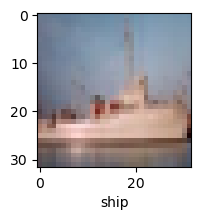

In [37]:
plot_sample(X_test,y_test,185)

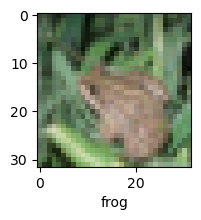

In [38]:
plot_sample(X_test,y_test,4)

In [39]:
classes[y_classes_new[4]]

'frog'

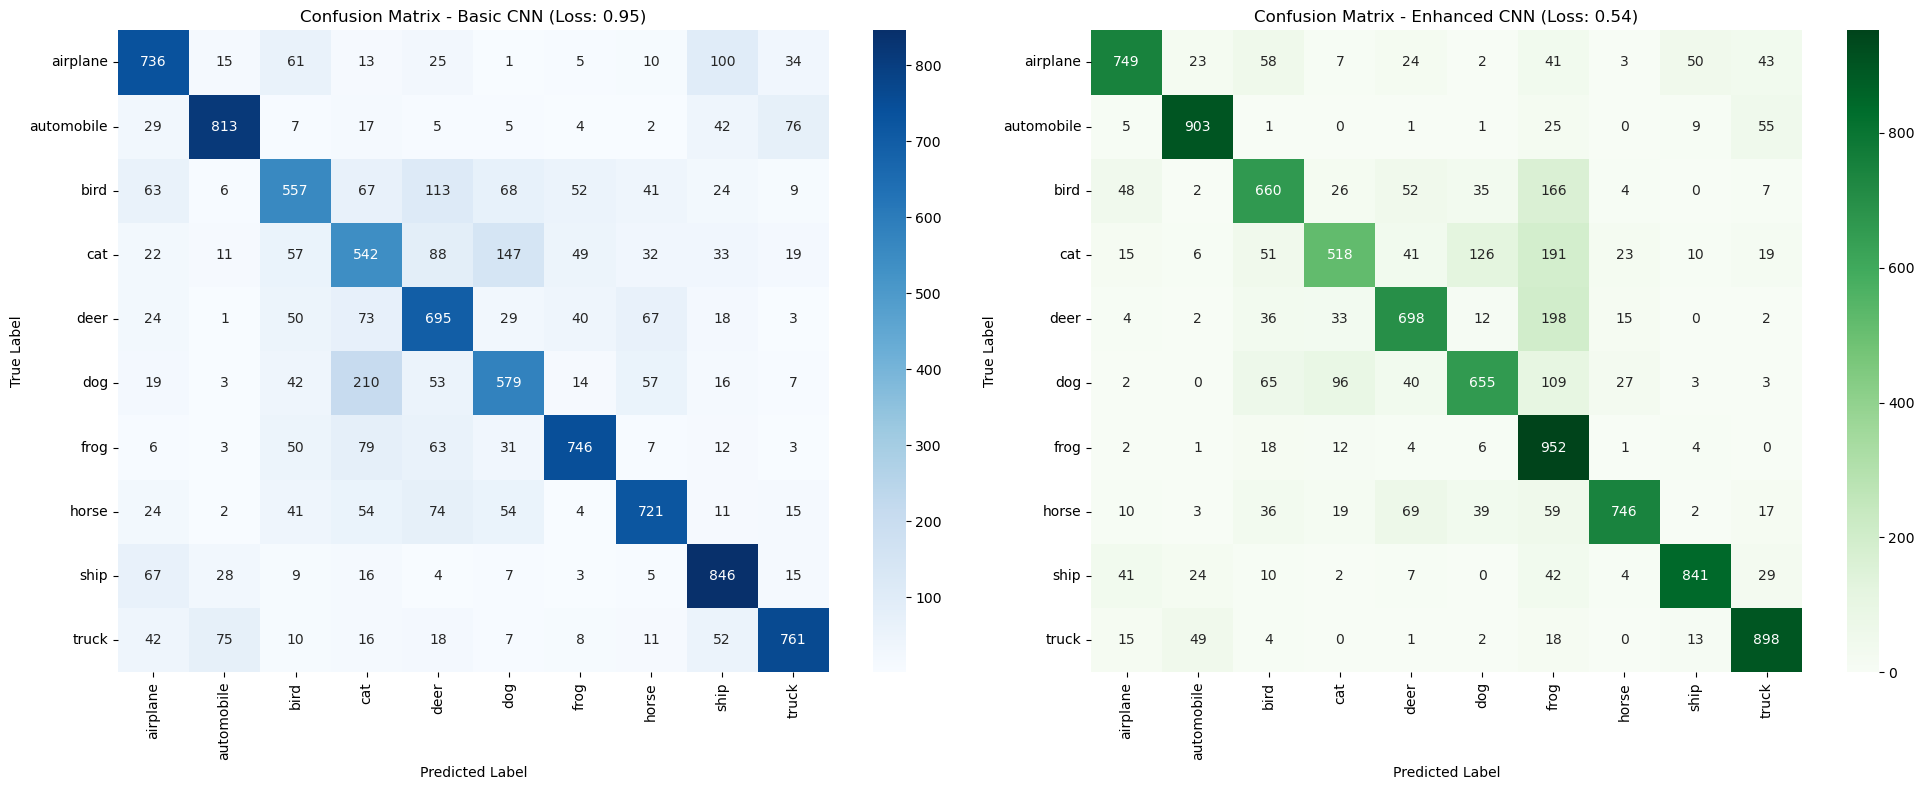

In [40]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

#Compute the confusion matrices
cm_basic = confusion_matrix(y_test, y_classes)
cm_enhanced = confusion_matrix(y_test, y_classes_new)

# Plot both side-by-side
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Basic CNN Heatmap
sns.heatmap(cm_basic, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=classes, yticklabels=classes)
axes[0].set_title('Confusion Matrix - Basic CNN (Loss: 0.95)')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Enhanced CNN Heatmap
sns.heatmap(cm_enhanced, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=classes, yticklabels=classes)
axes[1].set_title('Confusion Matrix - Enhanced CNN (Loss: 0.54)')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

In [43]:
print(" BASELINE CNN CLASSIFICATION REPORT ")
print(classification_report(y_test, y_classes, target_names=classes))

print(" ENHANCED CNN CLASSIFICATION REPORT ")
print(classification_report(y_test, y_classes_new, target_names=classes))

 BASELINE CNN CLASSIFICATION REPORT 
              precision    recall  f1-score   support

    airplane       0.71      0.74      0.72      1000
  automobile       0.85      0.81      0.83      1000
        bird       0.63      0.56      0.59      1000
         cat       0.50      0.54      0.52      1000
        deer       0.61      0.69      0.65      1000
         dog       0.62      0.58      0.60      1000
        frog       0.81      0.75      0.78      1000
       horse       0.76      0.72      0.74      1000
        ship       0.73      0.85      0.79      1000
       truck       0.81      0.76      0.78      1000

    accuracy                           0.70     10000
   macro avg       0.70      0.70      0.70     10000
weighted avg       0.70      0.70      0.70     10000

 ENHANCED CNN CLASSIFICATION REPORT 
              precision    recall  f1-score   support

    airplane       0.84      0.75      0.79      1000
  automobile       0.89      0.90      0.90      1000
    